# 01 - Analisi Esplorativa del Dataset (EDA)

**Obiettivo**: capire la struttura del dataset PE-malware prima di addestrare i modelli.

**Cosa risponde questo notebook**:
- Quanti campioni e quante feature ho?
- Il dataset è bilanciato? Qual è l'Imbalance Ratio?
- Ci sono valori mancanti (NaN)?
- Le feature hanno scale molto diverse?

---

## 1. Import delle librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

os.makedirs('../output', exist_ok=True)
print('Librerie caricate correttamente')

Librerie caricate correttamente


## 2. Caricamento del dataset

Carico `dataset_malwares.csv` (19.611 righe × 79 colonne).

In [2]:
df = pd.read_csv('../dataset/dataset_malwares.csv')

print(f'Shape: {df.shape}')
print(f'Numero campioni: {len(df):,}')
print(f'Numero colonne:  {df.shape[1]}')

Shape: (19611, 79)
Numero campioni: 19,611
Numero colonne:  79


## 3. Anteprima del dataset

In [3]:
df.head()

,Name,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,...,SectionMaxChar,SectionMainChar,DirectoryEntryImport,DirectoryEntryImportSize,DirectoryEntryExport,ImageDirectoryEntryExport,ImageDirectoryEntryImport,ImageDirectoryEntryResource,ImageDirectoryEntryException,ImageDirectoryEntrySecurity
0,VirusShare_a878ba26000edaac5c98eff4432723b3,23117,144,3,0,4,0,65535,0,184,...,3758096608,0,7,152,0,0,54440,77824,73728,0
1,VirusShare_ef9130570fddc174b312b2047f5f4cf0,23117,144,3,0,4,0,65535,0,184,...,3791650880,0,16,311,0,0,262276,294912,0,346112
2,VirusShare_ef84cdeba22be72a69b198213dada81a,23117,144,3,0,4,0,65535,0,184,...,3221225536,0,6,176,0,0,36864,40960,0,0
3,VirusShare_6bf3608e60ebc16cbcff6ed5467d469e,23117,144,3,0,4,0,65535,0,184,...,3224371328,0,8,155,0,0,356352,1003520,0,14109472
4,VirusShare_2cc94d952b2efb13c7d6bbe0dd59d3fb,23117,144,3,0,4,0,65535,0,184,...,3227516992,0,2,43,0,0,61440,73728,0,90624


## 4. Lista completa delle 79 colonne

In [4]:
print('Tutte le 79 colonne:')
print('-' * 60)
for i, col in enumerate(df.columns):
    print(f'{i:2d}. {col}')

Tutte le 79 colonne:
------------------------------------------------------------
 0. Name
 1. e_magic
 2. e_cblp
 3. e_cp
 4. e_crlc
 5. e_cparhdr
 6. e_minalloc
 7. e_maxalloc
 8. e_ss
 9. e_sp
10. e_csum
11. e_ip
12. e_cs
13. e_lfarlc
14. e_ovno
15. e_oemid
16. e_oeminfo
17. e_lfanew
18. Machine
19. NumberOfSections
20. TimeDateStamp
21. PointerToSymbolTable
22. NumberOfSymbols
23. SizeOfOptionalHeader
24. Characteristics
25. Magic
26. MajorLinkerVersion
27. MinorLinkerVersion
28. SizeOfCode
29. SizeOfInitializedData
30. SizeOfUninitializedData
31. AddressOfEntryPoint
32. BaseOfCode
33. ImageBase
34. SectionAlignment
35. FileAlignment
36. MajorOperatingSystemVersion
37. MinorOperatingSystemVersion
38. MajorImageVersion
39. MinorImageVersion
40. MajorSubsystemVersion
41. MinorSubsystemVersion
42. SizeOfHeaders
43. CheckSum
44. SizeOfImage
45. Subsystem
46. DllCharacteristics
47. SizeOfStackReserve
48. SizeOfStackCommit
49. SizeOfHeapReserve
50. SizeOfHeapCommit
51. LoaderFlags
52. Nu

## 5. Distribuzione del target

Verifico quanti malware (1) e quanti file legittimi (0) ho.


In [5]:
n_malware = (df['Malware'] == 1).sum()
n_legit   = (df['Malware'] == 0).sum()
n_total   = len(df)

print('Distribuzione target:')
print(f'   Malware (1): {n_malware:>6,} ({n_malware/n_total*100:.1f}%)')
print(f'   Legit   (0): {n_legit:>6,} ({n_legit/n_total*100:.1f}%)')
print(f'   Totale     : {n_total:>6,}')

Distribuzione target:
   Malware (1): 14,599 (74.4%)
   Legit   (0):  5,012 (25.6%)
   Totale     : 19,611


## 6. Calcolo dell'Imbalance Ratio (IR)

**IR** = rapporto tra classe maggioritaria e minoritaria.

- IR ≈ 1.0 → bilanciato
- 1.5 < IR < 3.0 → moderatamente sbilanciato
- IR > 3.0 → fortemente sbilanciato

In [6]:
IR = max(n_malware, n_legit) / min(n_malware, n_legit)
print(f'Imbalance Ratio (IR): {IR:.3f}')

if IR < 1.5:
    fascia = 'BILANCIATO'
elif IR < 3.0:
    fascia = 'MODERATAMENTE SBILANCIATO'
else:
    fascia = 'FORTEMENTE SBILANCIATO'

print(f'Fascia: {fascia}')
print(f'\nImplicazione: useremo stratify=y nel train_test_split')
print(f'              e guarderemo precision/recall/F1, non solo accuracy.')

Imbalance Ratio (IR): 2.913
Fascia: MODERATAMENTE SBILANCIATO

Implicazione: useremo stratify=y nel train_test_split
              e guarderemo precision/recall/F1, non solo accuracy.


## 7. Grafico distribuzione del target

Salvato: ../output/target_distribution.png


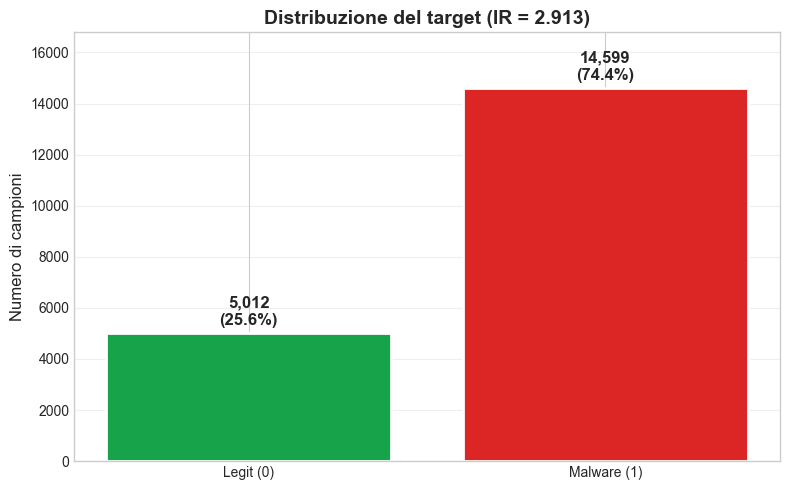

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')

colors = ['#16A34A', '#DC2626']  # verde legit, rosso malware
labels = ['Legit (0)', 'Malware (1)']
values = [n_legit, n_malware]

bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=2)

for bar, val in zip(bars, values):
    pct = val / n_total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title(f'Distribuzione del target (IR = {IR:.3f})', fontsize=14, fontweight='bold')
ax.set_ylabel('Numero di campioni', fontsize=12)
ax.set_ylim(0, max(values) * 1.15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../output/target_distribution.png', dpi=150, bbox_inches='tight')
print('Salvato: ../output/target_distribution.png')
plt.show()

## 8. Verifica valori mancanti (NaN)

In [8]:
nan_counts = df.isnull().sum()
total_nan = nan_counts.sum()

if total_nan == 0:
    print('Nessun valore NaN nel dataset. Pulizia non necessaria.')
else:
    print(f'Trovati {total_nan} valori NaN totali.')
    print('\nColonne con NaN:')
    print(nan_counts[nan_counts > 0])

Nessun valore NaN nel dataset. Pulizia non necessaria.


## 9. Statistiche descrittive delle prime 10 feature

Mostro media, std, min, max. **Noto subito che le feature hanno scale molto diverse** — questo motiva l'uso dello `StandardScaler` per il Perceptron.

In [9]:
df_num = df.drop(columns=['Name'])
df_num.iloc[:, :10].describe().round(2)

,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,e_csum
count,19611.0,19611.00,19611.00,19611.00,19611.00,19611.00,19611.00,19611.00,19611.00,19611.00
mean,23117.0,178.62,71.66,49.15,37.37,37.03,64178.74,10.42,226.47,29.69
std,0.0,987.20,1445.19,1212.20,864.52,915.83,9110.76,637.12,1249.68,1015.30
min,23117.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,23117.0,144.00,3.00,0.00,4.00,0.00,65535.00,0.00,184.00,0.00
50%,23117.0,144.00,3.00,0.00,4.00,0.00,65535.00,0.00,184.00,0.00
75%,23117.0,144.00,3.00,0.00,4.00,0.00,65535.00,0.00,184.00,0.00
max,23117.0,59448.00,63200.00,64613.00,43690.00,43690.00,65535.00,61436.00,65464.00,63262.00


**Osservazione**: notate la differenza di scala tra colonne come `e_magic` (~23117) e `e_minalloc` (~0-15). Per questo il **Perceptron** (sensibile alla scala) richiederà `StandardScaler` mentre Decision Tree e Random Forest no (lavorano per soglie).

## 10. Separazione X / y

Preparo lo split: rimuovo `Name` (identificativo testuale) e `Malware` (target). Restano **77 feature numeriche**.

In [10]:
X = df.drop(columns=['Name', 'Malware'])
y = df['Malware']

print(f'X shape: {X.shape}  (campioni x feature)')
print(f'y shape: {y.shape}  (solo target)')
print(f'\nNumero feature numeriche utilizzabili: {X.shape[1]}')

X shape: (19611, 77)  (campioni x feature)
y shape: (19611,)  (solo target)

Numero feature numeriche utilizzabili: 77


## 11. Riepilogo

In [11]:
print('=' * 60)
print('RIEPILOGO DEL DATASET')
print('=' * 60)
print(f'Campioni totali:    {n_total:,}')
print(f'Colonne totali:     {df.shape[1]}')
print(f'Feature numeriche:  {X.shape[1]} (escluse Name e Malware)')
print(f'Malware (label=1):  {n_malware:,} ({n_malware/n_total*100:.1f}%)')
print(f'Legit   (label=0):  {n_legit:,} ({n_legit/n_total*100:.1f}%)')
print(f'Imbalance Ratio:    {IR:.3f} ({fascia})')
print(f'Valori mancanti:    {total_nan}')
print('=' * 60)
print(f'\nCon train_test_split 80/20:')
print(f'   Training set: ~{int(n_total*0.8):,} campioni')
print(f'   Test set:     ~{int(n_total*0.2):,} campioni')

RIEPILOGO DEL DATASET
Campioni totali:    19,611
Colonne totali:     79
Feature numeriche:  77 (escluse Name e Malware)
Malware (label=1):  14,599 (74.4%)
Legit   (label=0):  5,012 (25.6%)
Imbalance Ratio:    2.913 (MODERATAMENTE SBILANCIATO)
Valori mancanti:    0

Con train_test_split 80/20:
   Training set: ~15,688 campioni
   Test set:     ~3,922 campioni
